# 2.4 — Обучение DPI-EVT

**Папка 2 «Обучение», подноутбук 4.** DPI-EVT — гибрид: энкодер DPI-Flow выводит латент θ, из
которого строится **развязанная (decoupled)** граница CRR и траектория PPR(N), а число циклов
до разжижения берётся **из самой кривой PPR** (`nliq_from_curve=True`). Это делает модель
согласованным источником PPR, CRR, риска и N_liq без утверждений о лидерстве внутри training notebook.
Актуальные места моделей определяются только в `results/tables/*.csv`, которые пересчитывает серия `3_*`.

Раньше DPI-EVT обучался отдельным скриптом `run_dpievt.py` и не имел своего ноутбука — из-за
чего при чистой папке `models/` он терял веса и выпадал из оценки. Этот ноутбук **штатно**
обучает, калибрует и сохраняет DPI-EVT, повторяя ту же процедуру:

* фиксированный seed, **косинусный планировщик LR** (`scheduler="cosine"`) — ключ к качеству;
* развязанная CRR + N_liq из кривой, без traj-residual и без внутренней калибровки θ;
* пост-hoc калибровка ширины интервалов (`fit_interval_scale`).

> Важно: качество DPI-EVT чувствительно к косинусному расписанию LR — обычный прогон
> `train_model` без планировщика заметно его ухудшает.


## Окружение и данные

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch
from liquefaction_ai import (get_default_config, load_population_artifact,
                             prepare_benchmark_dataset, train_model, set_global_seed)
from liquefaction_ai.training import write_hyperparams, read_hyperparams, save_trained_model
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, fit_interval_scale
from liquefaction_ai.models import DPIEvtNet

config = get_default_config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
population, config = load_population_artifact(DATA_DIR)
benchmark = prepare_benchmark_dataset(population, config, device)
train, val, test = benchmark["train"], benchmark["val"], benchmark["test"]
static_dim = train["static"].shape[1]; prefix_dim = train["prefix_summary"].shape[1]
seq_dim = train["seq_in"].shape[-1]
print("Источник:", DATA_DIR.name, "| train/val/test:",
      train["static"].shape[0], val["static"].shape[0], test["static"].shape[0],
      "| static_dim:", static_dim)

Источник: demo_run | train/val/test: 649 276 168 | static_dim: 34


## Шаг 1. Конфигурация и сборка модели

Параметры DPI-EVT соответствуют рабочей конфигурации: развязанная CRR, N_liq из кривой,
вероятностная голова и flow, без traj-residual и без внутренней калибровки θ.

**Порог разжижения.** `liq_threshold` берётся из общего конфига (`config.liq_threshold`) и
сохраняется в `models/dpi_evt/hyperparams.json`, поэтому training notebook, модельный артефакт
и оценка используют один и тот же порог. В текущем артефакте это `0.95`; итоговые значения
N_liq, CRR, Brier и CRPS не фиксируются в тексте ноутбука, а читаются из таблиц серии `3_*`.


In [2]:
model_kwargs = dict(
    static_dim=static_dim, prefix_dim=prefix_dim, seq_dim=seq_dim,
    seq_len=config.seq_len, prefix_len=config.prefix_len,
    max_cycle_reference=config.max_cycle_reference,
    probabilistic=True, use_flow=True,
    crr_mode="decoupled", nliq_from_curve=True, liq_threshold=config.liq_threshold,
    calibration_steps=0, use_traj_residual=False,
)
EPOCHS = config.publication_physics_epochs
set_global_seed(config.seed)          # единый сид проекта (детерминированная инициализация)
model = DPIEvtNet(**model_kwargs).to(device)
n_params = sum(p.numel() for p in model.parameters())
print("DPI-EVT параметров:", f"{n_params:,}", "| эпох:", EPOCHS)

DPI-EVT параметров: 213,632 | эпох: 80


## Шаг 2. Обучение с косинусным планировщиком LR

Это ключевой момент: косинусное расписание шага обучения существенно улучшает сходимость
DPI-EVT по сравнению с обычным прогоном.

In [3]:
model, history = train_model(model, train, val, epochs=EPOCHS, model_name="DPI-EVT",
                             config=config, device=device, track_metrics=True,
                             scheduler="cosine", ema_decay=0.0)
display(history)

[DPI-EVT] эпоха 01 | обучение=2.3698 | валидация=-0.3761 | val_AUROC=0.789 | val_RMSE=0.2020 | stale=0/12
[DPI-EVT] эпоха 02 | обучение=-0.5308 | валидация=-0.5420 | val_AUROC=0.871 | val_RMSE=0.1581 | stale=0/12
[DPI-EVT] эпоха 03 | обучение=-1.1904 | валидация=-0.6123 | val_AUROC=0.955 | val_RMSE=0.1801 | stale=0/12
[DPI-EVT] эпоха 04 | обучение=-1.4459 | валидация=-0.8390 | val_AUROC=0.971 | val_RMSE=0.1683 | stale=0/12
[DPI-EVT] эпоха 05 | обучение=-1.5443 | валидация=-0.9471 | val_AUROC=0.973 | val_RMSE=0.1386 | stale=0/12
[DPI-EVT] эпоха 06 | обучение=-1.7617 | валидация=-0.7966 | val_AUROC=0.975 | val_RMSE=0.1347 | stale=1/12
[DPI-EVT] эпоха 07 | обучение=-1.9084 | валидация=-0.4282 | val_AUROC=0.975 | val_RMSE=0.1356 | stale=2/12
[DPI-EVT] эпоха 08 | обучение=-2.0178 | валидация=1.9365 | val_AUROC=0.976 | val_RMSE=0.1555 | stale=3/12
[DPI-EVT] эпоха 09 | обучение=-2.0753 | валидация=0.9732 | val_AUROC=0.974 | val_RMSE=0.1387 | stale=4/12
[DPI-EVT] эпоха 10 | обучение=-2.0820 | 

,epoch,train_loss,val_loss,val_auroc,val_brier,val_traj_rmse,best_val_loss,epochs_without_improvement,best_epoch
0,1,2.369756,-0.376064,0.789110,0.164283,0.202029,-0.376064,0,1
1,2,-0.530791,-0.541963,0.871352,0.141034,0.158087,-0.541963,0,2
2,3,-1.190391,-0.612336,0.955239,0.106956,0.180074,-0.612336,0,3
3,4,-1.445863,-0.838986,0.971447,0.084806,0.168343,-0.838986,0,4
4,5,-1.544330,-0.947102,0.972650,0.101437,0.138563,-0.947102,0,5
5,6,-1.761682,-0.796564,0.975245,0.110982,0.134728,-0.947102,1,5
6,7,-1.908357,-0.428226,0.974865,0.104724,0.135561,-0.947102,2,5
7,8,-2.017819,1.936517,0.975752,0.086185,0.155543,-0.947102,3,5
8,9,-2.075292,0.973156,0.974359,0.092996,0.138721,-0.947102,4,5
9,10,-2.082028,0.669968,0.972460,0.095710,0.136687,-0.947102,5,5


## Шаг 3. Кривые обучения

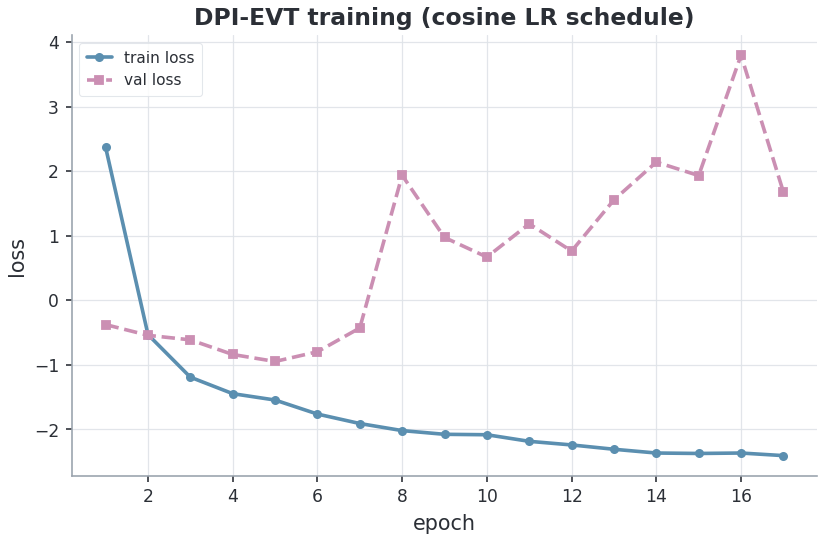

In [4]:
from liquefaction_ai.viz import new_figure, save_figure, QUALITATIVE, GRID
figw, fig = new_figure((7.4, 4.4)); ax = fig.add_subplot(111)
ax.plot(history["epoch"], history["train_loss"], "-o", color=QUALITATIVE[0], label="train loss", markersize=4)
ax.plot(history["epoch"], history["val_loss"], "--s", color="#CB8FB3", label="val loss", markersize=4)
ax.set_xlabel("epoch"); ax.set_ylabel("loss")
if "val_AUROC" in history.columns:
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(history["epoch"], history["val_AUROC"], "-^", color="#7FB286", label="val AUROC", markersize=4)
    ax2.set_ylabel("val AUROC"); ax2.set_ylim(0.9, 1.0)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8.5, loc="center right")
else:
    ax.legend(fontsize=8.5)
ax.set_title("DPI-EVT training (cosine LR schedule)")
save_figure(figw, "2_4_dpi_evt_training", SAVE_FIGS)
figw

## Шаг 4. Калибровка интервалов и оценка на тесте

`fit_interval_scale` подбирает масштаб ширины интервалов по валидации (целевое покрытие 90 %).
Затем считаем полный набор метрик на тестовой выборке.

In [5]:
calib_scale = fit_interval_scale(model, val, config, device, level=0.90)
metrics, _ = compute_metrics("DPI-EVT", collect_outputs(model, test, config, device), test, config)
keys = [("PPR Traj_RMSE", "Traj_RMSE"), ("Traj CRPS", "Traj_CRPS"), ("Calibration err", "Calibration_Error"),
        ("AUROC", "AUROC"), ("Brier", "Brier"), ("Physics violation", "Physics_Violation_Rate"),
        ("N_liq logMAE", "N_liq_logMAE"), ("N_liq MAE", "N_liq_MAE"), ("CRR RMSE", "CRR_RMSE")]
display(pd.DataFrame({"Metric": [k for k, _ in keys],
                      "DPI-EVT": [round(float(metrics[v]), 4) if metrics[v] == metrics[v] else None for _, v in keys]}))
print("calib_scale:", round(float(calib_scale), 3))

,Metric,DPI-EVT
0,PPR Traj_RMSE,0.1439
1,Traj CRPS,0.0784
2,Calibration err,0.0929
3,AUROC,0.9931
4,Brier,0.0562
5,Physics violation,0.0000
6,N_liq logMAE,0.2922
7,N_liq MAE,112.4632
8,CRR RMSE,0.1523


calib_scale: 0.9


## Шаг 5. Сохранение модели

Сохраняем веса, гиперпараметры (с `calib_scale`) и историю — в том же формате, что и остальные
модели, поэтому ноутбуки оценки серии 3 подхватывают DPI-EVT автоматически.

In [6]:
hp = {"model_type": "DPIEvtNet", "display_name": "DPI-EVT", "model_kwargs": model_kwargs}
write_hyperparams(MODELS_DIR, "dpi_evt", hp)
save_trained_model(model, MODELS_DIR, "dpi_evt", {**hp, "epochs": EPOCHS, "calib_scale": float(calib_scale)}, history)
print("DPI-EVT сохранён в", MODELS_DIR / "dpi_evt")

DPI-EVT сохранён в /Users/nick/Desktop/projects/liquefaction-ai/models/dpi_evt


## Итог

DPI-EVT обучен штатно (косинусный LR, развязанная CRR, N_liq из кривой), откалиброван и
сохранён в `models/dpi_evt`. Теперь он воспроизводимо входит в пайплайн: после `2_1`–`2_3`
запустите этот ноутбук — и серия `3_*` оценит полный набор моделей, включая DPI-EVT, по
единому grouped/site-heldout протоколу.

Запускать после смены датасета (ноутбук `1_0`) или при пустой папке `models/`.
